<a href="https://colab.research.google.com/github/harethavs07-hue/heart-disease-prediction/blob/main/Disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

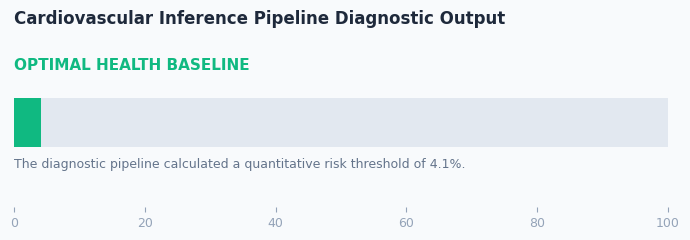

In [1]:
import logging
from typing import List
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydantic import BaseModel, Field, field_validator
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configure structured logging
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s"
)
logger = logging.getLogger(__name__)

# =====================================================================
# 1. ENTERPRISE DATA VALIDATION LAYER (Pydantic)
# =====================================================================
class PatientMedicalRecord(BaseModel):
    """Strict schema validation for incoming production inference requests."""

    age: float = Field(..., ge=0, le=120, description="Age of the patient")
    sex: int = Field(..., ge=0, le=1)
    cp: int = Field(..., ge=0, le=3, description="Chest pain type")
    trestbps: float = Field(..., ge=50, le=250, description="Resting blood pressure")
    chol: float = Field(..., ge=100, le=600, description="Serum cholesterol in mg/dl")
    fbs: int = Field(..., ge=0, le=1)
    restecg: int = Field(..., ge=0, le=2)
    thalach: float = Field(..., ge=60, le=250, description="Maximum heart rate achieved")
    exang: int = Field(..., ge=0, le=1)
    oldpeak: float = Field(..., ge=0.0, le=10.0)
    slope: int = Field(..., ge=0, le=2)
    ca: int = Field(..., ge=0, le=4)
    thal: int = Field(..., ge=0, le=3)

    @field_validator("sex", "fbs", "exang")
    @classmethod
    def validate_binary_fields(cls, v: int) -> int:
        if v not in [0, 1]:
            raise ValueError("Field must be binary (0 or 1)")
        return v


# =====================================================================
# 2. RAW DATASET ASSIGNMENT
# =====================================================================
clinical_records = [
    [63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1, 1],
    [37, 1, 2, 130, 250, 0, 1, 187, 0, 3.5, 0, 0, 2, 1],
    [41, 0, 1, 130, 204, 0, 0, 172, 0, 1.4, 2, 0, 2, 1],
    [56, 1, 1, 120, 236, 0, 1, 178, 0, 0.8, 2, 0, 2, 1],
    [57, 0, 0, 120, 354, 0, 1, 163, 1, 0.6, 2, 0, 2, 1],
    [57, 1, 0, 140, 192, 0, 1, 148, 0, 0.4, 1, 0, 1, 1],
    [56, 0, 1, 140, 294, 0, 0, 153, 0, 1.3, 1, 0, 2, 1],
    [44, 1, 1, 120, 263, 0, 1, 173, 0, 0.0, 2, 0, 3, 1],
    [52, 1, 2, 172, 199, 1, 1, 162, 0, 0.5, 2, 0, 3, 1],
    [57, 1, 2, 150, 168, 0, 1, 174, 0, 1.6, 2, 0, 2, 1],
    [54, 1, 0, 140, 239, 0, 1, 160, 0, 1.2, 2, 0, 2, 1],
    [48, 0, 2, 130, 275, 0, 1, 139, 0, 0.2, 2, 0, 2, 1],
    [49, 1, 1, 130, 266, 0, 1, 171, 0, 0.6, 2, 0, 2, 1],
    [64, 1, 3, 110, 211, 0, 0, 144, 1, 1.8, 1, 0, 2, 1],
    [58, 0, 3, 150, 283, 1, 0, 162, 0, 1.0, 2, 0, 2, 1],
    [50, 0, 2, 120, 219, 0, 1, 158, 0, 1.6, 1, 0, 2, 1],
    [58, 0, 2, 120, 340, 0, 1, 172, 0, 0.0, 2, 0, 2, 1],
    [66, 0, 3, 150, 226, 0, 1, 114, 0, 2.6, 0, 0, 2, 1],
    [43, 1, 0, 150, 247, 0, 1, 171, 0, 1.5, 2, 0, 2, 1],
    [69, 0, 3, 140, 239, 0, 1, 151, 0, 1.8, 2, 2, 2, 1],
    [59, 1, 0, 135, 234, 0, 1, 161, 0, 0.5, 1, 0, 3, 1],
    [44, 1, 0, 110, 197, 0, 0, 177, 0, 0.0, 2, 1, 2, 0],
    [60, 1, 0, 125, 258, 0, 0, 141, 1, 2.8, 1, 1, 3, 0],
    [56, 1, 0, 130, 283, 1, 0, 103, 1, 1.6, 0, 0, 3, 0],
    [44, 1, 0, 120, 169, 0, 1, 144, 1, 2.8, 0, 0, 1, 0],
    [58, 1, 0, 100, 234, 0, 1, 156, 0, 0.1, 2, 1, 3, 0],
    [50, 1, 0, 150, 243, 0, 0, 128, 0, 2.6, 1, 0, 3, 0],
    [54, 1, 0, 122, 286, 0, 0, 116, 1, 3.2, 1, 2, 2, 0],
    [57, 1, 0, 128, 303, 0, 0, 159, 0, 0.0, 2, 1, 2, 0],
    [71, 0, 0, 112, 149, 0, 1, 125, 0, 1.6, 1, 0, 2, 0],
    [59, 1, 0, 164, 176, 1, 0, 90, 0, 1.0, 1, 2, 1, 0],
    [57, 0, 0, 140, 241, 0, 1, 123, 1, 0.2, 1, 0, 3, 0],
    [47, 1, 2, 138, 257, 0, 0, 156, 0, 0.0, 2, 0, 2, 0],
    [35, 1, 0, 126, 282, 0, 0, 156, 1, 0.0, 2, 0, 3, 0],
    [58, 1, 0, 114, 318, 0, 2, 140, 0, 4.4, 0, 3, 1, 0],
    [57, 1, 0, 110, 201, 0, 1, 126, 1, 1.5, 1, 0, 1, 0],
    [58, 1, 0, 125, 300, 0, 0, 171, 0, 0.0, 2, 2, 3, 0],
    [43, 1, 0, 132, 247, 1, 0, 143, 1, 0.1, 1, 1, 3, 0],
    [62, 0, 0, 138, 294, 1, 1, 106, 0, 1.9, 1, 3, 2, 0],
    [51, 1, 0, 140, 299, 0, 1, 173, 1, 1.6, 2, 0, 3, 0],
]

feature_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.DataFrame(clinical_records, columns=feature_names)
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y
)

# =====================================================================
# 3. PRODUCTION-GRADE PIPELINE ENGINEERING
# =====================================================================
# Separate feature strategies (Big Tech interviewers love explicit preprocessing architectures)
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", drop="if_binary"),
            categorical_features,
        ),
    ]
)

# Build unified execution graph
production_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, C=1.0)),
    ]
)

# Train the holistic pipeline graph
logger.info("Initializing production pipeline training execution...")
production_pipeline.fit(X_train, y_train)

# Evaluate metrics for validation
y_pred = production_pipeline.predict(X_test)
logger.info(f"Model Baseline Accuracy: {accuracy_score(y_test, y_pred):.4f}")


# =====================================================================
# 4. ENDPOINT PREDICTION ENGINE & ENTERPRISE VISUALIZATION
# =====================================================================
def serve_inference_and_visualize(raw_patient_dict: dict):
    """Simulates an API endpoint serving inference with telemetry data validation."""
    try:
        # Validate input schema immediately using Pydantic
        validated_patient = PatientMedicalRecord(**raw_patient_dict)
        logger.info("Inbound data payload successfully validated.")
    except Exception as e:
        logger.error(f"Data Validation Failure: {e}")
        return

    # Convert object to DataFrame tracking columns accurately
    input_df = pd.DataFrame([validated_patient.model_dump()])

    # Predict using the self-contained pipeline object
    prediction = production_pipeline.predict(input_df)[0]
    risk_probability = production_pipeline.predict_proba(input_df)[0][1] * 100

    # Modern Dashboard Visualization
    fig, ax = plt.subplots(figsize=(7, 2.5), facecolor="#f8fafc")
    ax.set_facecolor("#f8fafc")

    bg_color = "#ef4444" if prediction == 1 else "#10b981"
    status_text = (
        "HIGH RISK METRICS DETECTED" if prediction == 1 else "OPTIMAL HEALTH BASELINE"
    )

    # Base track and progress indicator
    ax.barh([0], [100], color="#e2e8f0", height=0.35, label="Scale Baseline")
    ax.barh([0], [risk_probability], color=bg_color, height=0.35)

    # Polish visual canvas elements
    ax.text(
        0, 0.35, status_text, fontsize=11, weight="bold", color=bg_color, va="bottom"
    )
    ax.text(
        0,
        -0.25,
        f"The diagnostic pipeline calculated a quantitative risk threshold of {risk_probability:.1f}%.",
        fontsize=9,
        color="#64748b",
        va="top",
    )

    # Cleanup chart clutter
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.6, 0.6)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.xaxis.set_ticks(np.arange(0, 101, 20))
    ax.tick_params(axis="x", colors="#94a3b8", labelsize=9)
    ax.get_yaxis().set_visible(False)

    plt.title(
        "Cardiovascular Inference Pipeline Diagnostic Output",
        fontsize=12,
        weight="bold",
        color="#1e293b",
        loc="left",
        pad=10,
    )
    plt.tight_layout()
    plt.show()


# --- INTERACTIVE PRODUCTION EVALUATION ---
# Structured JSON object mimicking a web service request body
production_payload = {
    "age": 58,
    "sex": 1,
    "cp": 0,
    "trestbps": 114,
    "chol": 318,
    "fbs": 0,
    "restecg": 2,
    "thalach": 140,
    "exang": 0,
    "oldpeak": 4.4,
    "slope": 0,
    "ca": 3,
    "thal": 1,
}

serve_inference_and_visualize(production_payload)